# Elasticity Model EDA

## 1. Objective

The goal of this analysis is to understand the relationship between price and demand and determine whether price elasticity can be reliably estimated.

## 2. Import Libraries

In [20]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
from src.utils.db import run_query
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Data

In [3]:
feature = run_query('''
    SELECT * FROM feature_layer.ml_features
''')

display(feature)

c:\Users\user\Desktop\Data Science\Machine Learning\Inventory ML System\notebooks\..\src\utils\db.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,sale_date,product_id,total_quantity,product_avg_qty,avg_selling_price,total_discount,avg_landing_cost,avg_margin_pct,has_discount,discount_rate,...,price_change_pct,l0_category_id,l1_category_id,l2_category_id,brand_name,product_age_days,abc_class,xyz_class,abc_xyz_class,demand_cov
0,2022-04-01,1,264,0.0,59.965957,46.0,55.482678,0.074774,1,0.002906,...,NaN,16,1573,1297,nutrela,0,A,X,AX,0.270206
1,2022-04-02,1,241,264.0,59.884956,0.0,52.466809,0.123733,0,0.000000,...,-0.001351,16,1573,1297,nutrela,1,A,X,AX,0.270206
2,2022-04-03,1,293,252.5,59.936330,112.0,53.991995,0.098592,1,0.006380,...,0.000858,16,1573,1297,nutrela,2,A,X,AX,0.270206
3,2022-04-04,1,162,266.0,59.940789,24.0,52.438330,0.125095,1,0.002471,...,0.000074,16,1573,1297,nutrela,3,A,X,AX,0.270206
4,2022-04-05,1,144,240.0,59.938462,24.0,54.500408,0.090714,1,0.002780,...,-0.000039,16,1573,1297,nutrela,4,A,X,AX,0.270206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702941,2022-07-09,488733,1,0.0,784.000000,0.0,752.390800,0.040300,0,0.000000,...,NaN,163,1117,697,unknown,0,C,X,CX,0.000000
702942,2022-07-10,488735,1,0.0,724.000000,0.0,694.795000,0.040300,0,0.000000,...,NaN,163,1117,697,unknown,0,C,X,CX,0.000000
702943,2022-07-09,488737,1,0.0,489.000000,0.0,503.281000,-0.029200,0,0.000000,...,NaN,163,981,981,phy,0,C,X,CX,0.000000
702944,2022-07-09,488739,1,0.0,735.000000,0.0,756.002000,-0.028600,0,0.000000,...,NaN,163,1115,358,unknown,0,C,X,CX,0.000000


## 4. Price Variation Analysis

To estimate elasticity, sufficient price variation per product is required.

In [10]:
feature.groupby("product_id")["avg_selling_price"].nunique().describe()

count    15765.000000
mean        17.559404
std         22.186743
min          1.000000
25%          2.000000
50%          7.000000
75%         24.000000
max         81.000000
Name: avg_selling_price, dtype: float64

#### Insights:
- The distribution says there is average variation of price 18.
- Most of the products have price variations, but least 25% of products have no variations in prices.

In [16]:
df_elastic = feature.groupby("product_id").filter(
    lambda x : x["avg_selling_price"].nunique() > 3
)

## 5. Price vs Demand

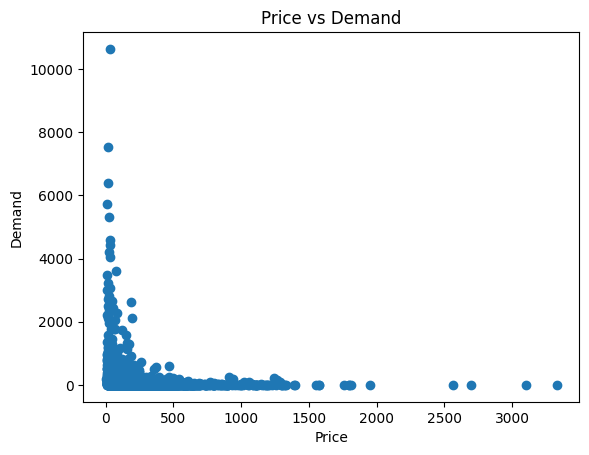

In [19]:
sample = df_elastic.sample(5000)

plt.scatter(sample["avg_selling_price"], sample["total_quantity"])
plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Price vs Demand")
plt.show()

- It shows high demand variations at low price.
- The relationship is highly non-linear and skewed

## 6. Log-Log Transformation

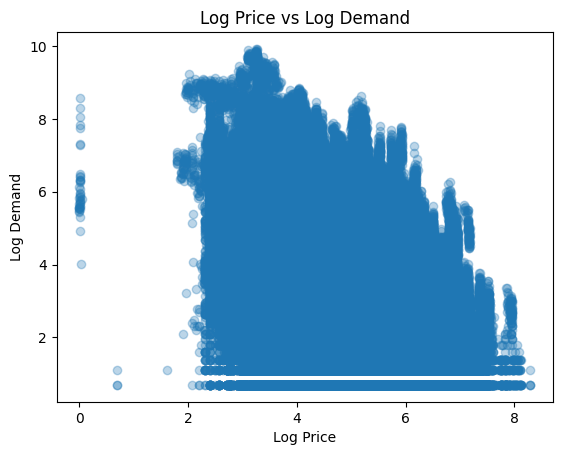

In [ ]:
df_elastic['log_selling_price'] = np.log1p(df_elastic['avg_selling_price'])
df_elastic['log_quantity'] = np.log1p(df_elastic['total_quantity'])

plt.scatter(df_elastic['log_selling_price'], df_elastic['log_quantity'])
plt.xlabel("Log Price")
plt.ylabel("Log Demand")
plt.title("Log Price vs Log Demand")
plt.show()

- Weak negative relationship between price and demand.

## 7. Correlation Analysis

In [23]:
feature[["avg_selling_price", "total_quantity"]].corr()

,avg_selling_price,total_quantity
avg_selling_price,1.000000,-0.095885
total_quantity,-0.095885,1.000000


- Weak negative relationship between quantity and selling price.

## 8. Discount Impact Analysis

In [24]:
feature.groupby("has_discount")["total_quantity"].mean()

has_discount
0     16.391844
1    217.565826
Name: total_quantity, dtype: float64

- Demand is strongly influanced by discount presence.

## 9. Discount Rate Analysis

In [25]:
feature[["discount_rate", "total_quantity"]].corr()

,discount_rate,total_quantity
discount_rate,1.000000,0.010748
total_quantity,0.010748,1.000000


- Discount Magnitude Having Limited Correlation.

## 10. Conclusion

- The log-log relationship indicates a weak negative elasticity.
- high variance suggests that demand is influenced more by promotions, temporal effects, and product-specific factors than price alone.
- The approach is defined log - log regression with price and other factors.
- Go with regression model with log parameters.
- - price
- - discount_rate
- - qty_lag1
- - rolling_mean_7
- - day_of_week
- - month

Loading data...


c:\Users\user\Desktop\Data Science\Machine Learning\Inventory ML System\notebooks\..\src\utils\db.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


Loaded 702,946 rows
cat=19, elasticity=-0.281 R²=0.723, n=2248
cat=28, elasticity=-0.206 R²=0.702, n=7646
cat=29, elasticity=-0.194 R²=0.654, n=10526
cat=33, elasticity=-0.437 R²=0.653, n=5023
cat=48, elasticity=-0.569 R²=0.628, n=3585
cat=50, elasticity=+0.023 R²=0.683, n=15950
cat=51, elasticity=+0.064 R²=0.631, n=6186
cat=57, elasticity=+0.042 R²=0.760, n=464
cat=62, elasticity=-0.294 R²=0.703, n=1020
cat=75, elasticity=+0.082 R²=0.735, n=897
cat=80, elasticity=-0.315 R²=0.745, n=2192
cat=82, elasticity=-0.170 R²=0.696, n=711
cat=85, elasticity=-0.217 R²=0.571, n=698
cat=87, elasticity=-0.049 R²=0.681, n=2078
cat=91, elasticity=-0.078 R²=0.586, n=2366
cat=96, elasticity=-0.150 R²=0.467, n=1367
cat=105, elasticity=-0.078 R²=0.725, n=5213
cat=107, elasticity=+0.038 R²=0.667, n=2981
cat=108, elasticity=-0.344 R²=0.742, n=3938
cat=109, elasticity=-0.364 R²=0.693, n=2506
cat=120, elasticity=-0.103 R²=0.170, n=65
cat=123, elasticity=-0.503 R²=0.724, n=5248
cat=126, elasticity=-0.232 R²=0.